---

# <span style="color:#1F4E79;">25340 Digital Ocean</span>
### <span style="color:#2E86AB;">Sea Surface Temperature Anomalies and Atmospheric Drivers of the North Atlantic Marine Heatwaves</span>

---

## <span style="color:#1F4E79;">Table of Contents</span>
- [Part 1: Data Collection](#Part-1:-Data-Collection)
- [Part 2: Data Investigation](#Part-2:-Data-Investigation)
- [Part 3: Variable Map Distribution](#Part-3:-Variable-Map-Distribution)
- [Part 4: Data Analysis](#Part-4:-Data-Analysis)

---

In [1]:
# Import necessary libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
import copernicusmarine
import warnings
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

c:\Users\natal\repos\OceanCourses\.ocean\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
# Part 1: Data Collection

The data will be collected from 2 periods (5 months) for 2 Marine Heatwave events:
1. December 2015 - April 2016
2. May 2023 - September 2023

If the date is not downloaded on your computer please run the DataDownload.ipynb file to get the neccessary files.

---
# Part 2: Data Investigation

In [17]:
# Load the dataset (Sea Surface Temperature) for both 2016 and 2023
ds_2016 = xr.open_dataset("Data/atl_sst_mhw_2016.nc")
ds_2023 = xr.open_dataset("Data/atl_sst_mhw_2023.nc")

# Load the dataset (Total Cloud Cover) for both 2016 and 2023
ds_tcc_2016 = xr.open_dataset("Data/era5_tcc_mhw_2016.nc")
ds_tcc_2023 = xr.open_dataset("Data/era5_tcc_mhw_2023.nc")

# Load the dataset (100m U and V wind components) for both 2016 and 2023
ds_u_2016 = xr.open_dataset("Data/era5_u-wind_mhw_2016.nc")
ds_u_2023 = xr.open_dataset("Data/era5_u-wind_mhw_2023.nc")
ds_v_2016 = xr.open_dataset("Data/era5_v-wind_mhw_2016.nc")
ds_v_2023 = xr.open_dataset("Data/era5_v-wind_mhw_2023.nc")

# Merge the datasets for 2016 and 2023 into a single dataset for each variable (for plotting purposes)
ds = xr.concat([ds_2016['analysed_sst'], ds_2023['analysed_sst']], dim='time')
dt = xr.concat([ds_tcc_2016['tcc'], ds_tcc_2023['tcc']], dim='time')

In [13]:
# Variable name mapping with units for clearer graph titles/labels
var_names = {
    'analysed_sst': 'Sea Surface Temperature (°C)',
    'tcc': 'Total Cloud Cover (%)',
    '100m_u_component_of_wind': '100m U Component of Wind (m/s)',
    '100m_v_component_of_wind': '100m V Component of Wind (m/s)'
}

# Convert temperature from Kelvin to degree Celsius when needed in all ds datasets
for ds in [ds_2016, ds_2023]:
    analysed_sst_mean = float(ds['analysed_sst'].mean(skipna=True).values)
    if analysed_sst_mean > 100.0:
        ds['analysed_sst'] = ds['analysed_sst'] - 273.15
        ds['analysed_sst'].attrs['units'] = 'degC'

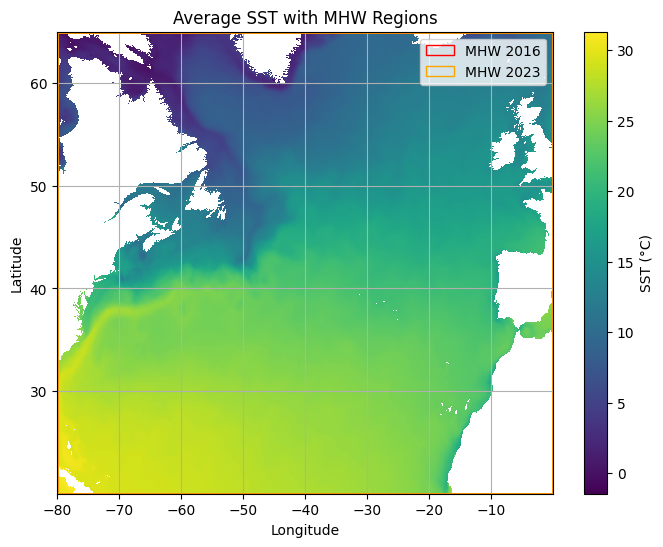

In [4]:
MHW_2016 = {
    "minimum_longitude": -80.0,
    "maximum_longitude": 0.0,
    "minimum_latitude": 20.0,
    "maximum_latitude": 65.0,
}

MHW_2023 = {
    "minimum_longitude": -80.0,
    "maximum_longitude": 0.0,
    "minimum_latitude": 20.0,
    "maximum_latitude": 65.0,
}

# Plot on the map the region of the 2016 MHW
plt.figure(figsize=(8, 6))
plt.pcolormesh(ds.longitude, ds.latitude, ds.analysed_sst.mean(dim="time"), shading='auto', cmap='viridis')
plt.colorbar(label='SST (°C)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Average SST with MHW Regions")
plt.grid()

# Add rectangles for MHW regions
plt.gca().add_patch(plt.Rectangle((MHW_2016["minimum_longitude"], MHW_2016["minimum_latitude"]),
                                  MHW_2016["maximum_longitude"] - MHW_2016["minimum_longitude"],
                                  MHW_2016["maximum_latitude"] - MHW_2016["minimum_latitude"],
                                  edgecolor='red', facecolor='none', lw=2, label='MHW 2016'))

plt.gca().add_patch(plt.Rectangle((MHW_2023["minimum_longitude"], MHW_2023["minimum_latitude"]),
                                  MHW_2023["maximum_longitude"] - MHW_2023["minimum_longitude"],
                                  MHW_2023["maximum_latitude"] - MHW_2023["minimum_latitude"],
                                  edgecolor='orange', facecolor='none', lw=2, label='MHW 2023'))

plt.legend(handles=[Patch(edgecolor='red', facecolor='none', label='MHW 2016'),
                    Patch(edgecolor='orange', facecolor='none', label='MHW 2023')])

plt.savefig("Figures/MHW_Regions_Map.png", dpi=300)
plt.show()

---
# Part 3: Variable Map Distribution

In [72]:
def plot_mean_std_maps(ds,variable, years_range, depth_sel=None):
    """ Compute and plot time-mean and time-std maps for one variable."""

    # Get full variable name and select the variable
    var_full_name = var_names.get(variable, variable)
    da = ds[variable]

    # # Depth handling
    # if 'depth' in da.dims:
    #     if depth_sel is None:
    #         depth_sel = float(da['depth'].isel(depth=0).values)
    #     da = da.sel(depth=depth_sel, method='nearest')
    #     print(f"{var_full_name}: using depth={float(da['depth'].values):.2f}")

    # Compute time mean and std, skip the NaN values
    da_mean = da.mean(dim='time', skipna=True)
    da_std = da.std(dim='time', skipna=True)

    fig, axes = plt.subplots(2, 1, figsize=(8, 8))

    # Plot the mean graph
    da_mean.plot(
        ax=axes[0],
        cmap='viridis',
        cbar_kwargs={'label': f'{var_full_name}'})
    
    axes[0].set_title(f"{var_full_name}: Time Mean {years_range}")
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')

    # Plot the STD graph
    da_std.plot(
        ax=axes[1],
        cmap='magma',
        cbar_kwargs={'label': f'{var_full_name}'})
    
    axes[1].set_title(f"{var_full_name}: Time Std {years_range}")
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')

    plt.tight_layout()
    plt.show()



def plot_mean_std_maps_era5(ds, variable, years_range, region=None):
    """Compute and plot time-mean and time-std maps for ERA5 using the SST region box."""

    if region is None:
        region = {
            "minimum_longitude": -80.0,
            "maximum_longitude": 0.0,
            "minimum_latitude": 20.0,
            "maximum_latitude": 65.0,
        }

    lon_min = region['minimum_longitude']
    lon_max = region['maximum_longitude']
    lat_min = region['minimum_latitude']
    lat_max = region['maximum_latitude']

    var_full_name = var_names.get(variable, variable)
    da = ds[variable]

    # ERA5 commonly stores valid_time as temporal axis; keep latitude/longitude for mapping.
    temporal_dim = 'valid_time' if 'valid_time' in da.dims else 'time'
    reduce_non_spatial = [d for d in da.dims if d not in [temporal_dim, 'latitude', 'longitude']]
    if reduce_non_spatial:
        da = da.mean(dim=reduce_non_spatial, skipna=True)

    # Detect ERA5 files where coordinate labels are swapped.
    lon_range = (float(np.nanmin(da['longitude'].values)), float(np.nanmax(da['longitude'].values)))
    lat_range = (float(np.nanmin(da['latitude'].values)), float(np.nanmax(da['latitude'].values)))

    def _overlap_span(a_min, a_max, b_min, b_max):
        lo_a, hi_a = min(a_min, a_max), max(a_min, a_max)
        lo_b, hi_b = min(b_min, b_max), max(b_min, b_max)
        return max(0.0, min(hi_a, hi_b) - max(lo_a, lo_b))

    lon_span_with_lon_box = _overlap_span(lon_range[0], lon_range[1], lon_min, lon_max)
    lat_span_with_lon_box = _overlap_span(lat_range[0], lat_range[1], lon_min, lon_max)
    lon_span_with_lat_box = _overlap_span(lon_range[0], lon_range[1], lat_min, lat_max)

    # If longitude only touches the lon box (e.g., overlap near 0) but clearly matches lat box, swap labels.
    if lon_span_with_lon_box < 5.0 and lat_span_with_lon_box > 5.0 and lon_span_with_lat_box > 5.0:
        da = da.rename({'longitude': 'latitude', 'latitude': 'longitude'})

    # Convert longitude from 0..360 to -180..180 so region bounds like -80..0 work directly.
    lon_vals = da['longitude'].values
    if float(np.nanmax(lon_vals)) > 180:
        da = da.assign_coords(longitude=(((da['longitude'] + 180) % 360) - 180)).sortby('longitude')

    # Build robust latitude and longitude slices for either ascending or descending coordinates.
    lat_vals = da['latitude'].values
    if lat_vals[0] <= lat_vals[-1]:
        lat_slice = slice(lat_min, lat_max)
    else:
        lat_slice = slice(lat_max, lat_min)

    lon_vals = da['longitude'].values
    if lon_vals[0] <= lon_vals[-1]:
        lon_slice = slice(lon_min, lon_max)
    else:
        lon_slice = slice(lon_max, lon_min)

    # Apply the same map box used for SST.
    da_box = da.sel(longitude=lon_slice, latitude=lat_slice)

    if da_box.sizes.get('longitude', 0) == 0 or da_box.sizes.get('latitude', 0) == 0:
        lon_cov = (float(np.nanmin(da['longitude'].values)), float(np.nanmax(da['longitude'].values)))
        lat_cov = (float(np.nanmin(da['latitude'].values)), float(np.nanmax(da['latitude'].values)))
        print(
            f"No ERA5 data inside selected box lon [{lon_min}, {lon_max}], lat [{lat_min}, {lat_max}]. "
            f"Dataset coverage is lon [{lon_cov[0]:.2f}, {lon_cov[1]:.2f}], lat [{lat_cov[0]:.2f}, {lat_cov[1]:.2f}]."
        )
        return

    # Ensure numeric dtype for plotting.
    try:
        da_box = da_box.astype(float)
    except Exception:
        print(f"Variable '{variable}' is not numeric after preprocessing; cannot plot.")
        return

    da_mean = da_box.mean(dim=temporal_dim, skipna=True)
    da_std = da_box.std(dim=temporal_dim, skipna=True)

    # Enforce canonical 2D map order for reliable x/y plotting.
    if 'latitude' in da_mean.dims and 'longitude' in da_mean.dims:
        da_mean = da_mean.transpose('latitude', 'longitude')
        da_std = da_std.transpose('latitude', 'longitude')

    # Try geographic map background with coastlines; fallback to plain axes if Cartopy is unavailable.
    try:
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
        use_cartopy = True
    except Exception:
        use_cartopy = False

    if use_cartopy:
        fig, axes = plt.subplots(
            2,
            1,
            figsize=(11, 8),
            subplot_kw={'projection': ccrs.PlateCarree()}
        )

        plot_specs = [
            (da_mean, axes[0], 'viridis', f"{var_full_name}: Time Mean {years_range}"),
            (da_std, axes[1], 'magma', f"{var_full_name}: Time Std {years_range}")
        ]

        for field, ax, cmap, title in plot_specs:
            mesh = field.plot(
                ax=ax,
                x='longitude',
                y='latitude',
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                add_colorbar=False
            )

            cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)
            cbar.set_label(var_full_name)

            ax.coastlines(resolution='110m', linewidth=0.8, color='black')
            ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='none', alpha=1.0, zorder=3)
            ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='gray')
            ax.set_title(title)
            ax.set_xlim(lon_min, lon_max)
            ax.set_ylim(lat_min, lat_max)

            # Show numeric lon/lat labels without E/W/N/S suffixes.
            grid = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', color='gray', alpha=0.5)
            grid.top_labels = False
            grid.right_labels = False
            grid.xformatter = LongitudeFormatter(direction_label=False, degree_symbol='')
            grid.yformatter = LatitudeFormatter(direction_label=False, degree_symbol='')

    else:
        fig, axes = plt.subplots(2, 1, figsize=(11, 8))

        da_mean.plot(
            ax=axes[0],
            x='longitude',
            y='latitude',
            cmap='viridis',
            cbar_kwargs={'label': f'{var_full_name}'}
        )
        axes[0].set_title(f"{var_full_name}: Time Mean {years_range}")
        axes[0].set_xlabel('Longitude')
        axes[0].set_ylabel('Latitude')
        axes[0].set_xlim(lon_min, lon_max)
        axes[0].set_ylim(lat_min, lat_max)

        da_std.plot(
            ax=axes[1],
            x='longitude',
            y='latitude',
            cmap='magma',
            cbar_kwargs={'label': f'{var_full_name}'}
        )
        axes[1].set_title(f"{var_full_name}: Time Std {years_range}")
        axes[1].set_xlabel('Longitude')
        axes[1].set_ylabel('Latitude')
        axes[1].set_xlim(lon_min, lon_max)
        axes[1].set_ylim(lat_min, lat_max)

    plt.tight_layout()
    plt.show()

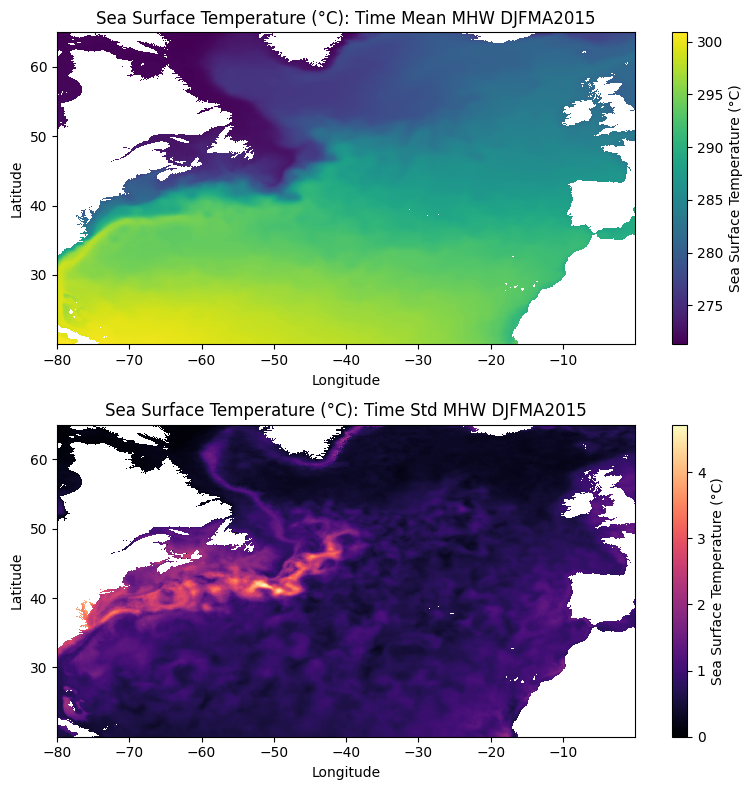

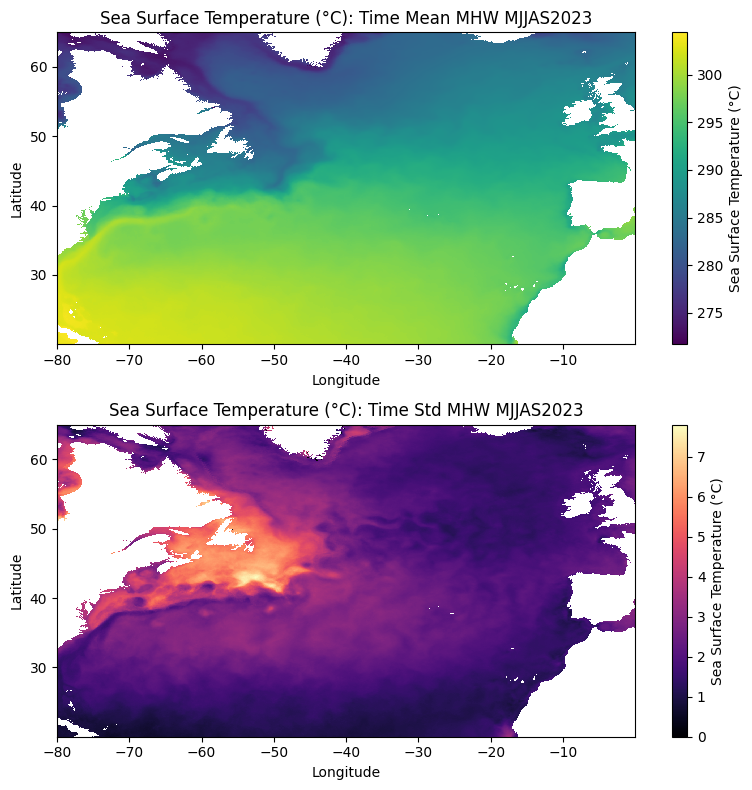

In [73]:
plot_mean_std_maps(ds_2016, 'analysed_sst', 'MHW DJFMA2015')
plot_mean_std_maps(ds_2023, 'analysed_sst', 'MHW MJJAS2023')

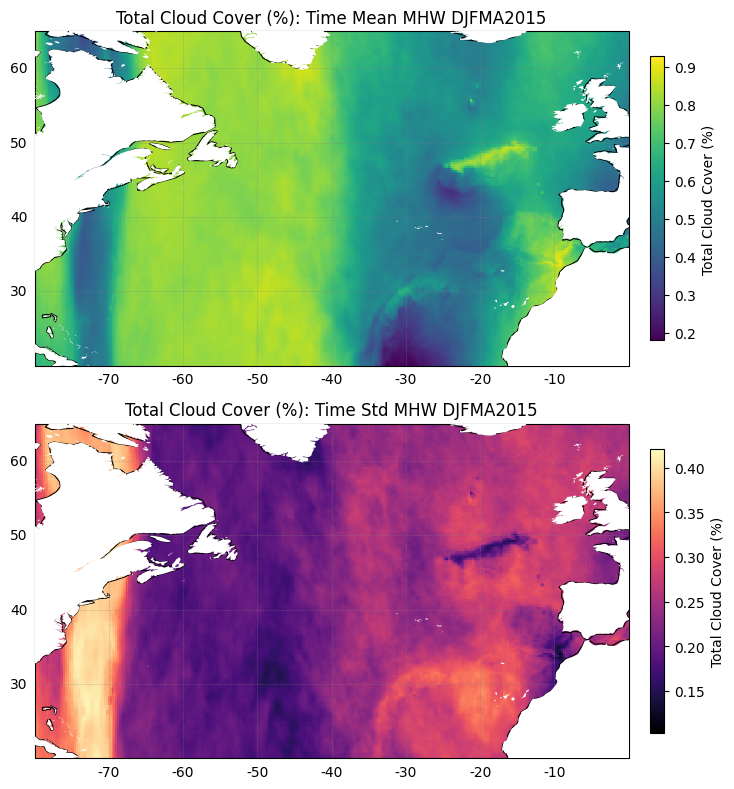

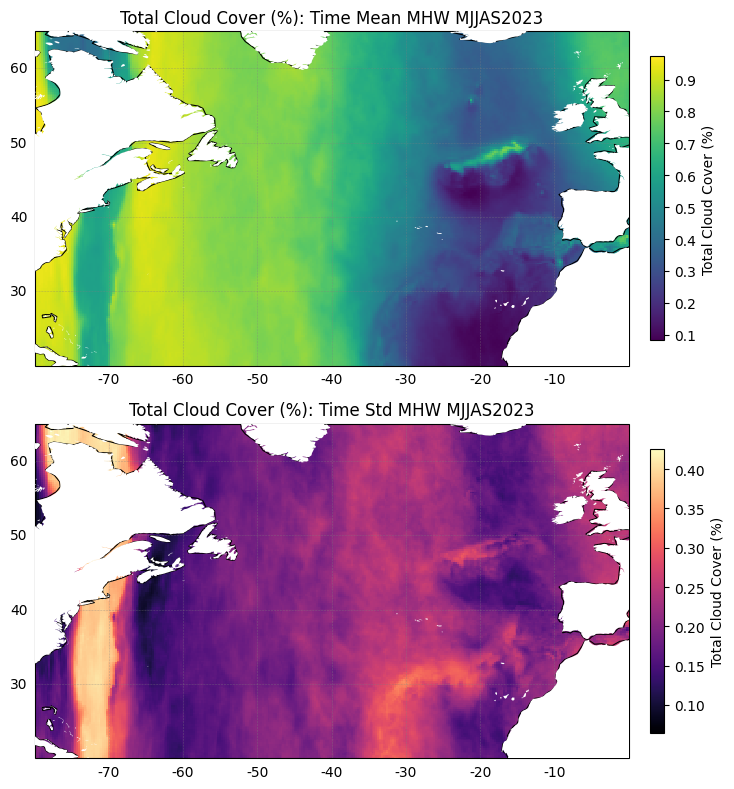

In [64]:
plot_mean_std_maps_era5(ds_tcc_2016, 'tcc', 'MHW DJFMA2015')
plot_mean_std_maps_era5(ds_tcc_2023, 'tcc', 'MHW MJJAS2023')

---
# Part 4: Data Analysis

In [8]:
def plot_temporal_variability_area(ds, variable, lon_min, lon_max, lat_min, lat_max, show_plot=True):
    """Plot area-averaged temporal variability for a selected lon/lat box."""

    # Get full variable name for titles/labels
    var_full_name = var_names.get(variable, variable)
    da = ds[variable]

    # Build latitude slice for either ascending or descending coordinates.
    lat_vals = da['latitude'].values
    if lat_vals[0] <= lat_vals[-1]:
        lat_slice = slice(lat_min, lat_max)
    else:
        lat_slice = slice(lat_max, lat_min)

    # Handle both -180..180 and 0..360 longitude conventions.
    lon_vals = da['longitude'].values
    lon_a = lon_min
    lon_b = lon_max
    if float(np.nanmax(lon_vals)) > 180 and lon_a < 0:
        lon_a = lon_a % 360
        lon_b = lon_b % 360

    # Get the spatial subset for the selected box.
    if lon_a <= lon_b:
        da_area = da.sel(longitude=slice(lon_a, lon_b), latitude=lat_slice).copy(deep=True)
    else:
        da_area_1 = da.sel(
            longitude=slice(lon_a, float(np.nanmax(lon_vals))),
            latitude=lat_slice
        )
        da_area_2 = da.sel(
            longitude=slice(float(np.nanmin(lon_vals)), lon_b),
            latitude=lat_slice
        )
        da_area = xr.concat([da_area_1, da_area_2], dim='longitude').copy(deep=True)

    # Handle depth-dependent variables so result is always a 1D time series
    if 'depth' in da_area.dims:
        da_area = da_area.isel(depth=0)
        var_full_name = f"{var_full_name} (surface)"

    # ERA5 may store real timeline in valid_time; reduce all other dims.
    temporal_dim = 'valid_time' if 'valid_time' in da_area.dims else 'time'
    reduce_dims = [d for d in da_area.dims if d != temporal_dim]
    if reduce_dims:
        ts = da_area.mean(dim=reduce_dims, skipna=True)
    else:
        ts = da_area
    if temporal_dim != 'time':
        ts = ts.rename({temporal_dim: 'time'})

    if np.all(np.isnan(ts.values)):
        print(
            f"No data found for {variable} in selected area: "
            f"lon [{lon_min}, {lon_max}], lat [{lat_min}, {lat_max}]"
        )
        return ts

    if show_plot:
        fig, ax = plt.subplots(figsize=(12, 4.2), dpi=120)
        ax.plot(ts['time'].values, ts.values, color="#227FD5", linewidth=2.0, marker='o', markersize=4, label=var_full_name)

        # Calculate and display mean, min, max values on the plot
        mean_v = float(np.nanmean(ts.values))
        min_v = float(np.nanmin(ts.values))
        max_v = float(np.nanmax(ts.values))
        std_v = float(np.nanstd(ts.values))
        ax.text(
            0.01,
            0.98,
            f"Mean={mean_v:.2f}\nMin={min_v:.2f}\nMax={max_v:.2f}\nSTD={std_v:.2f}",
            transform=ax.transAxes,
            va='top',
            fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='0.7')
        )

        ax.set_title(f"Area-Mean Time Series: {var_full_name}")
        ax.set_xlabel('Time')
        ax.set_ylabel(var_full_name)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
        ax.grid(alpha=0.25, linestyle='--')
        ax.legend(frameon=False, loc='best')

        plt.tight_layout()
        plt.show()

    return ts

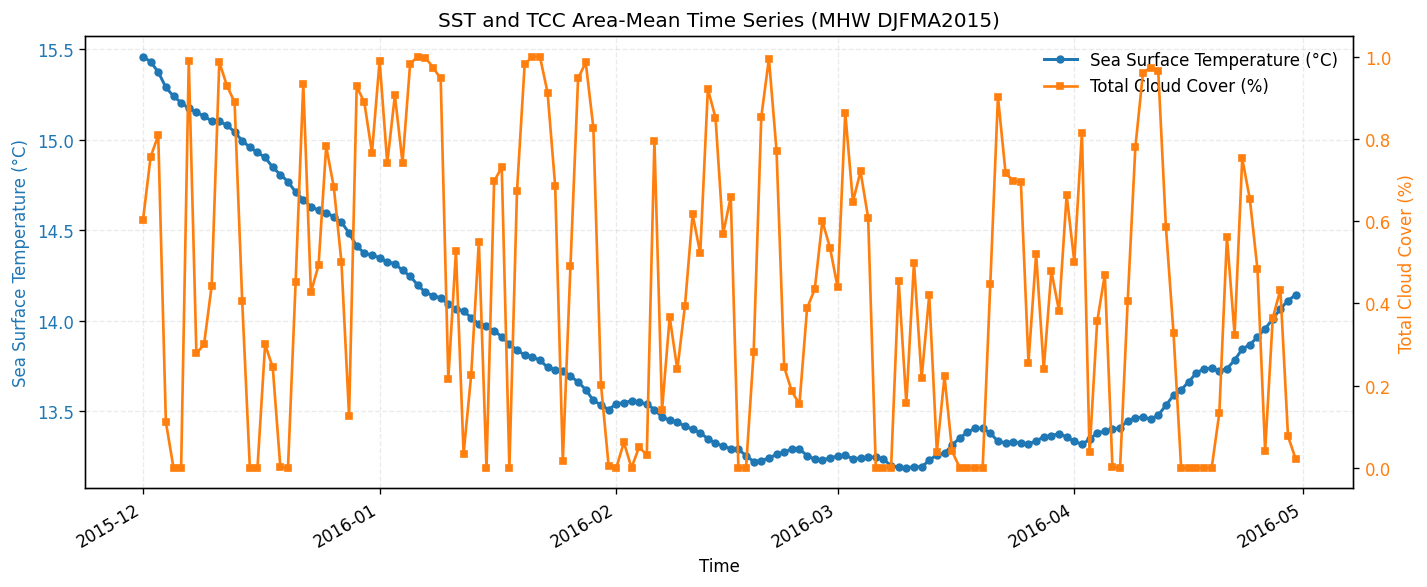

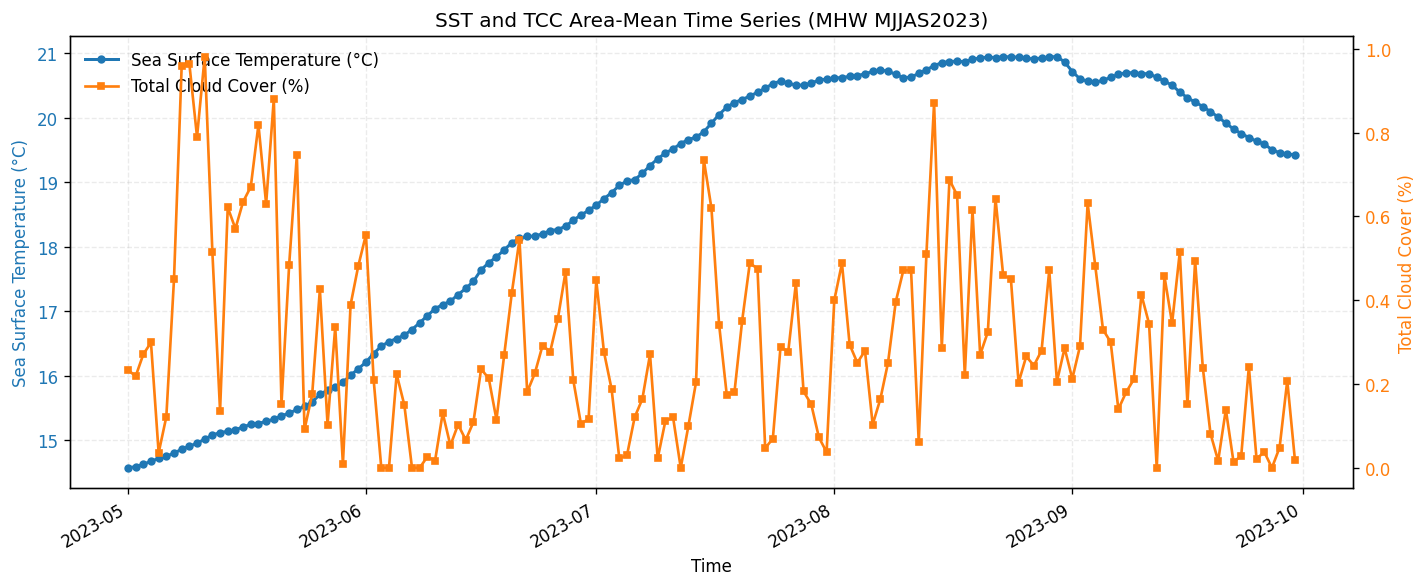

In [9]:
# Plot SST and TCC together for BOTH MHW events (2016 and 2023)
mhw_options = {
    '2016': {
        'region': MHW_2016,
        'years_label': 'MHW DJFMA2015',
        'sst_ds': ds_2016,
        'tcc_ds': ds_tcc_2016
    },
    '2023': {
        'region': MHW_2023,
        'years_label': 'MHW MJJAS2023',
        'sst_ds': ds_2023,
        'tcc_ds': ds_tcc_2023
    }
}

for mhw_key in ['2016', '2023']:
    cfg = mhw_options[mhw_key]
    region = cfg['region']

    sst_ts = plot_temporal_variability_area(
        cfg['sst_ds'],
        'analysed_sst',
        region['minimum_longitude'],
        region['maximum_longitude'],
        region['minimum_latitude'],
        region['maximum_latitude'],
        show_plot=False
).to_series().dropna()

    tcc_ts = plot_temporal_variability_area(
        cfg['tcc_ds'],
        'tcc',
        region['minimum_longitude'],
        region['maximum_longitude'],
        region['minimum_latitude'],
        region['maximum_latitude'],
        show_plot=False
).to_series().dropna()

    fig, ax1 = plt.subplots(figsize=(12, 5), dpi=120)
    ax1.plot(
        sst_ts.index,
        sst_ts.values,
        color='tab:blue',
        marker='o',
        markersize=4,
        linewidth=1.8,
        label='Sea Surface Temperature (°C)'
    )
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Sea Surface Temperature (°C)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax1.get_xticklabels(), rotation=30, ha='right')
    ax1.grid(alpha=0.25, linestyle='--')

    ax2 = ax1.twinx()
    if tcc_ts.empty:
        ax2.text(
            0.98,
            0.95,
            'TCC not available for this region in this dataset',
            transform=ax2.transAxes,
            ha='right',
            va='top',
            fontsize=9,
            color='tab:orange',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='0.7')
        )
    else:
        ax2.plot(
            tcc_ts.index,
            tcc_ts.values,
            color='tab:orange',
            marker='s',
            markersize=4,
            linewidth=1.6,
            label='Total Cloud Cover (%)'
        )
    ax2.set_ylabel('Total Cloud Cover (%)', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best', frameon=False)

    ax1.set_title(f"SST and TCC Area-Mean Time Series ({cfg['years_label']})")
    plt.tight_layout()
    plt.show()

In [10]:
# Plot time series for sea surface temperature and total cloud cover for the MHW regions in 2016 and 2023
def get_regional_series(ds, variable, region):
    """Return regional mean time series for one variable, or None if empty."""
    da = ds[variable]
    
    # Build robust latitude slice for either ascending or descending coordinates.
    lat_vals = da["latitude"].values
    lat_min = region["minimum_latitude"]
    lat_max = region["maximum_latitude"]
    if lat_vals[0] <= lat_vals[-1]:
        lat_slice = slice(lat_min, lat_max)
    else:
        lat_slice = slice(lat_max, lat_min)
    
    # Handle both -180..180 and 0..360 longitude conventions.
    lon_vals = da["longitude"].values
    lon_min = region["minimum_longitude"]
    lon_max = region["maximum_longitude"]
    
    if float(np.nanmax(lon_vals)) > 180 and lon_min < 0:
        lon_min = lon_min % 360
        lon_max = lon_max % 360
    
    # Select the regional box.
    if lon_min <= lon_max:
        da_region = da.sel(
            longitude=slice(lon_min, lon_max),
            latitude=lat_slice
        )
    else:
        # Dateline-wrapping case: merge two longitude slices.
        da_region_1 = da.sel(
            longitude=slice(lon_min, float(np.nanmax(lon_vals))),
            latitude=lat_slice
        )
        da_region_2 = da.sel(
            longitude=slice(float(np.nanmin(lon_vals)), lon_max),
            latitude=lat_slice
        )
        da_region = xr.concat([da_region_1, da_region_2], dim="longitude")
    
    # ERA5 tcc can use valid_time as the real timeline; keep that as temporal axis.
    temporal_dim = "valid_time" if "valid_time" in da_region.dims else "time"
    reduce_dims = [d for d in da_region.dims if d != temporal_dim]
    if reduce_dims:
        da_region = da_region.mean(dim=reduce_dims, skipna=True)
    if temporal_dim != "time":
        da_region = da_region.rename({temporal_dim: "time"})
    
    ts = da_region.to_series().dropna()
    if ts.empty:
        ds_lon_min = float(np.nanmin(lon_vals))
        ds_lon_max = float(np.nanmax(lon_vals))
        ds_lat_min = float(np.nanmin(lat_vals))
        ds_lat_max = float(np.nanmax(lat_vals))
        print(
            f"No data found for {variable} in region [{region['minimum_longitude']}, {region['maximum_longitude']}] lon, "
            f"[{region['minimum_latitude']}, {region['maximum_latitude']}] lat. "
            f"Dataset coverage is lon [{ds_lon_min:.2f}, {ds_lon_max:.2f}], lat [{ds_lat_min:.2f}, {ds_lat_max:.2f}]."
        )
        return None
    
    return ts
    
def plot_time_series(ds, variable, region, years_range):
    """Plot time series of a variable averaged over a specified region."""
    var_full_name = var_names.get(variable, variable)
    ts = get_regional_series(ds, variable, region)
    if ts is None:
        print(f"Skipping {variable} for {years_range}.")
        return
    
    plt.figure(figsize=(12, 6))
    ts.plot(marker="o")
    plt.title(f"{var_full_name} Time Series ({years_range})")
    plt.xlabel("Time")
    plt.ylabel(var_full_name)
    plt.grid()
    plt.show()
    
def plot_sst_tcc_same_graph(ds_sst, ds_tcc, region, years_range):
    """Plot SST and TCC on one chart using dual y-axes."""
    sst_ts = get_regional_series(ds_sst, "analysed_sst", region)
    tcc_ts = get_regional_series(ds_tcc, "tcc", region)
    
    if sst_ts is None and tcc_ts is None:
        print(f"No SST or TCC data available for {years_range}.")
        return
    
    plt.figure(figsize=(12, 6))
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    line_handles = []
    line_labels = []
    
    if sst_ts is not None:
        ln1 = ax1.plot(sst_ts.index, sst_ts.values, color="tab:blue", marker="o", label=var_names["analysed_sst"])[0]
        ax1.set_ylabel(var_names["analysed_sst"], color="tab:blue")
        ax1.tick_params(axis="y", labelcolor="tab:blue")
        line_handles.append(ln1)
        line_labels.append(var_names["analysed_sst"])
    else:
        ax1.set_ylabel(var_names["analysed_sst"], color="tab:blue")
    
    ax2 = ax1.twinx()
    if tcc_ts is not None:
        ln2 = ax2.plot(tcc_ts.index, tcc_ts.values, color="tab:orange", marker="s", label=var_names["tcc"])[0]
        ax2.set_ylabel(var_names["tcc"], color="tab:orange")
        ax2.tick_params(axis="y", labelcolor="tab:orange")
        line_handles.append(ln2)
        line_labels.append(var_names["tcc"])
    else:
        ax2.set_ylabel(var_names["tcc"], color="tab:orange")
    
    ax1.set_xlabel("Time")
    ax1.set_title(f"SST and TCC Time Series ({years_range})")
    ax1.grid()
    if line_handles:
        ax1.legend(line_handles, line_labels, loc="best")
    plt.tight_layout()
    plt.show()

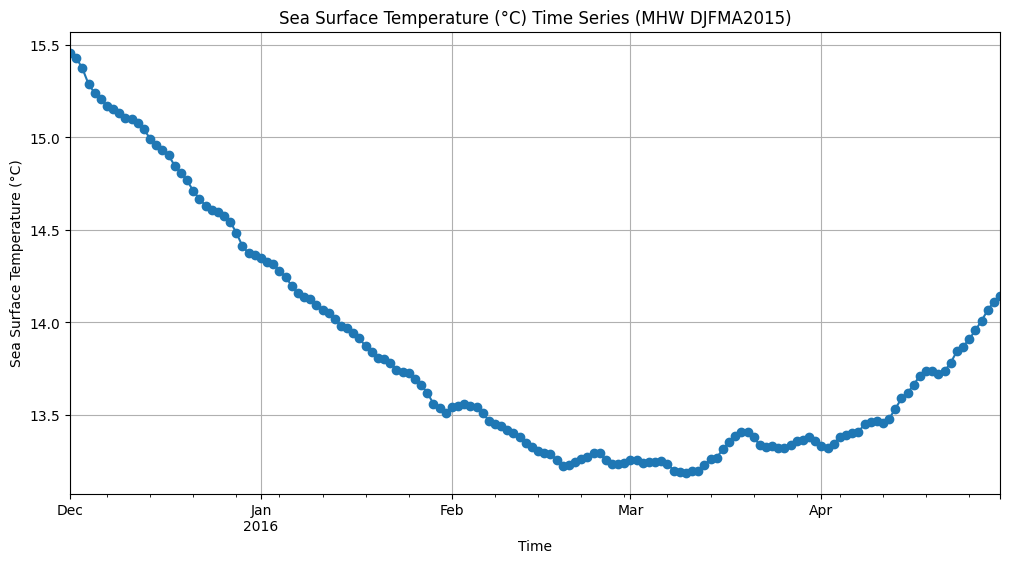

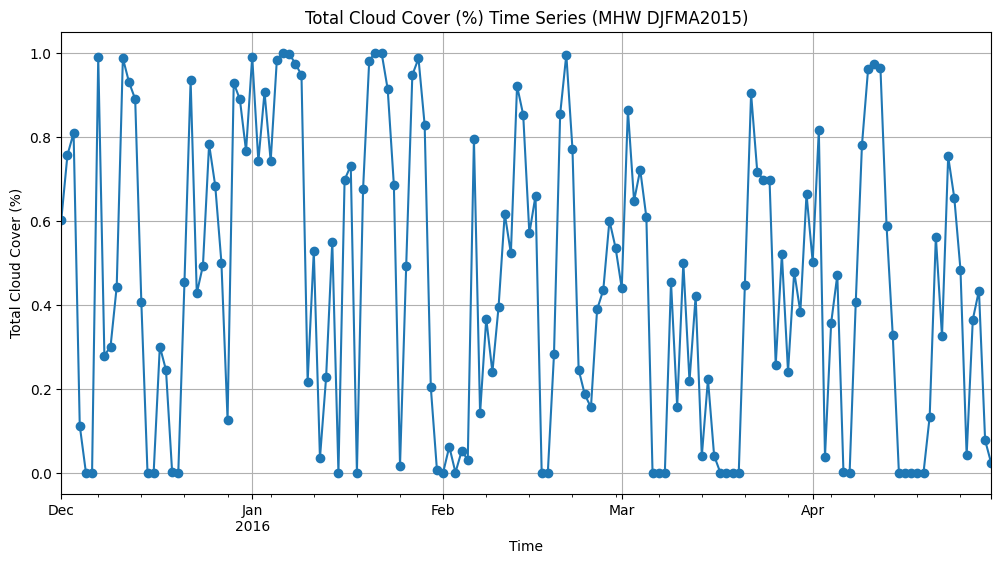

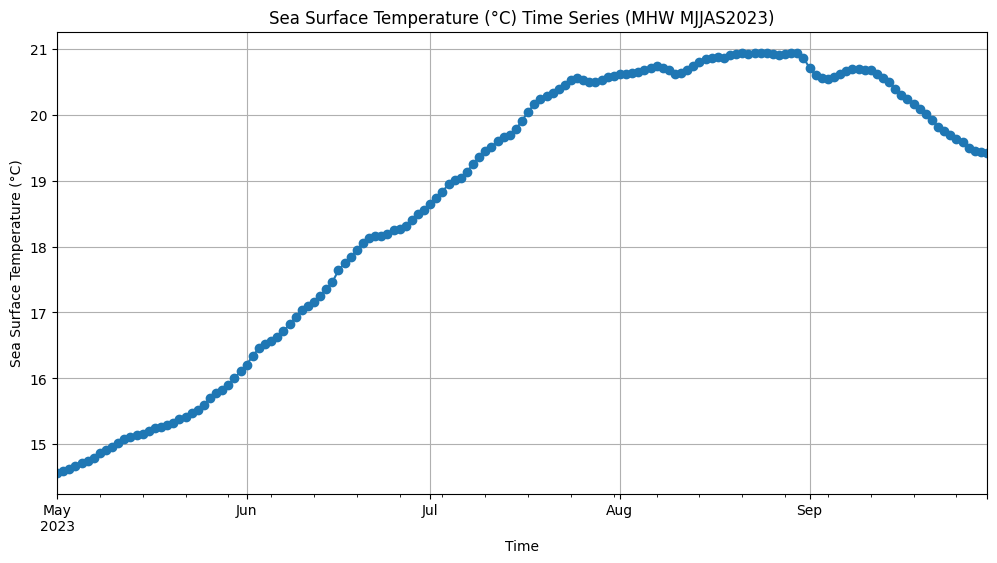

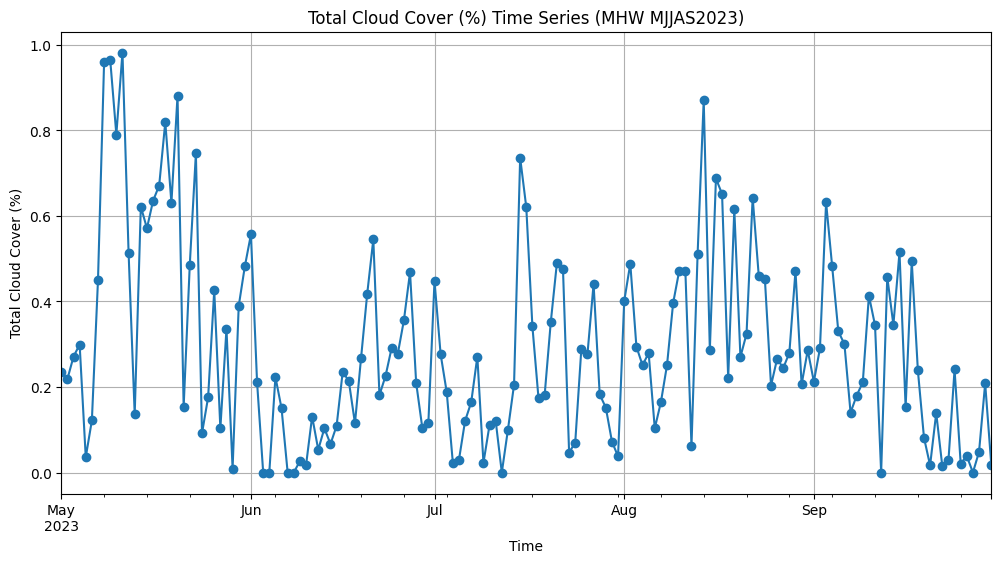

In [11]:
plot_time_series(ds_2016, 'analysed_sst', MHW_2016, 'MHW DJFMA2015')
plot_time_series(ds_tcc_2016, 'tcc', MHW_2016, 'MHW DJFMA2015')
plot_time_series(ds_2023, 'analysed_sst', MHW_2023, 'MHW MJJAS2023')
plot_time_series(ds_tcc_2023, 'tcc', MHW_2023, 'MHW MJJAS2023')

# Combined SST + TCC plots on the same graph
# plot_sst_tcc_same_graph(ds_2016, ds_tcc_2016, MHW_2016, 'MHW DJFMA2015')
# plot_sst_tcc_same_graph(ds_2023, ds_tcc_2023, MHW_2023, 'MHW MJJAS2023')